In [1]:
from dsc80_utils import *

# Lecture 18 – Classifier Evaluation, Model Fairness, Career Advice

## DSC 80, Spring 2026

## Final Exam 📝

- **Tue Jun 10**.
    - Will write the exam to take about 2.5 hours, so you'll have a lot of time to double check your work.
- Two 8.5"x11" cheat sheets allowed of your own creation (handwritten on tablet, then printed is okay.)
- Covers every lecture, lab, and project.
- Similar format to the midterm: mix of fill-in-the-blank, multiple choice, and free response.
    - I use `pandas` fill-in-the-blank questions to test your ability to read and write code, not just write code from scratch, which is why they can feel tricker.
- Questions on final about pre-Midterm material will be marked as "M". Your Midterm grade will be the higher of your (z-score adjusted) grades on the Midterm and the questions marked as "M" on the final.
- Practice by working through old exams at [practice.dsc80.com](https://practice.dsc80.com).
- Also review the revision recording and lecture podcasts 

### Agenda 📆

- Logistic regression.
- Model fairness.
- Conclusion

Aside: [MLU Explain](https://mlu-explain.github.io/) is a **great** resource with visual explanations of many of our recent topics (cross-validation, random forests, precision and recall, etc.).

## Recap: Random Forests

### Main idea: 

Train a bunch of decision trees, then have them **vote** on a prediction!

- **Problem:** If you use the same training data, you will always get the same tree.
- **Solution:** Introduce randomness into training procedure to get different trees.

### Idea 1: Bootstrap the training data

- We can bootstrap the training data $T$ times, then train one tree on each resample.
- Also known as bagging (Bootstrap AGgregating). In general, combining different predictors together is a useful technique called **ensemble learning**.
- For decision trees though, doesn't make trees different enough from each other (e.g. if you have one really strong predictor, it'll always be the first split).

### Idea 2: Only use a subset of features

- At each split, take a random subset of $ m $ features instead of choosing from all $ d $ of them.
- Rule of thumb: $ m \approx \sqrt d $ seems to work well.
- Key idea: For ensemble learning, you want the individual predictors to have low bias, high variance, and be uncorrelated with each other. That way, when you average them together, you have low bias AND low variance.

- **Random forest algorithm:** Fit $ T $ trees by using bagging and a random subset of features at each split. Predict by taking a vote from the $ T $ trees.

## Recap: Classifier Evaluation

<center>⬇️</center>

| | Predicted Negative | Predicted Positive |
| --- | --- | --- |
| **Actually Negative** | TN ✅ | FP ❌ |
| **Actually Positive** | FN ❌ | TP ✅ |

<br>

<center><i>The <b>confusion matrix</b> above is organized the same way that <code>sklearn</code>'s confusion matrices are (but differently than in the wolf example).</i></center>

$$\text{accuracy} = \frac{TP + TN}{TP + FP + FN + TN} \: \: \: \:  \: \: \: \: \text{precision} = \frac{TP}{TP + FP} \: \: \: \:  \: \: \: \: \text{recall} = \frac{TP}{TP + FN}$$


### Precision and recall

<center><img src="imgs/Precisionrecall.svg.png" width=30%></center>

<center>(<a href="https://en.wikipedia.org/wiki/Precision_and_recall">source</a>)</center>

## Logistic regression

### Wisconsin breast cancer dataset

The Wisconsin breast cancer dataset (WBCD) is a commonly-used dataset for demonstrating binary classification. It is built into `sklearn.datasets`.

In [47]:
from sklearn.datasets import load_breast_cancer
loaded = load_breast_cancer() # explore the value of `loaded`!
data = loaded['data']
labels = 1 - loaded['target']
cols = loaded['feature_names']
bc = pd.DataFrame(data, columns=cols)

In [48]:
bc.head()

,mean radius,mean texture,mean perimeter,mean area,...,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,...,0.71,0.27,0.46,0.12
1,20.57,17.77,132.90,1326.0,...,0.24,0.19,0.28,0.09
2,19.69,21.25,130.00,1203.0,...,0.45,0.24,0.36,0.09
3,11.42,20.38,77.58,386.1,...,0.69,0.26,0.66,0.17
4,20.29,14.34,135.10,1297.0,...,0.40,0.16,0.24,0.08


1 stands for "malignant", i.e. cancerous, and 0 stands for "benign", i.e. safe.

In [49]:
labels

array([1, 1, 1, ..., 1, 1, 0])

In [50]:
pd.Series(labels).value_counts(normalize=True)

0    0.63
1    0.37
Name: proportion, dtype: float64

Our goal is to use the features in `bc` to predict `labels`.

### Logistic regression

Logistic _regression_ is a linear _classification_ technique that builds upon linear regression. It models **the probability of belonging to class 1, given a feature vector**:

$$P(y = 1 | \vec{x}) = \sigma (\underbrace{w_0 + w_1 x^{(1)} + w_2 x^{(2)} + ... + w_d x^{(d)}}_{\text{linear regression model}})$$

Here, $\sigma(t) = \frac{1}{1 + e^{-t}}$ is the **sigmoid** function; its outputs are between 0 and 1 (which means they can be interpreted as probabilities).

🤔 **Question**: Suppose our logistic regression model predicts the probability that a tumor is malignant is 0.75. What class do we predict – malignant or benign? What if the predicted probability is 0.3?

🙋 **Answer**: We have to pick a threshold (e.g. 0.5)!
- If the predicted probability is above the threshold, we predict malignant (1).
- Otherwise, we predict benign (0).
- In practice, we use cross validation to decide this threshold.

### Fitting a logistic regression model

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [52]:
X_train, X_test, y_train, y_test = train_test_split(bc, labels)

In [53]:
clf = LogisticRegression(max_iter=10000)
clf.fit(X_train, y_train)

LogisticRegression(max_iter=10000)

How did `clf` come up with 1s and 0s?

In [54]:
clf.predict(X_test)

array([0, 1, 1, ..., 1, 0, 0])

It turns out that the predicted labels come from applying a **threshold** of 0.5 to the predicted probabilities. We can access the predicted probabilities using the `predict_proba` method:

In [55]:
# [:, 1] refers to the predicted probabilities for class 1.
clf.predict_proba(X_test)

array([[0.99, 0.01],
       [0.  , 1.  ],
       [0.01, 0.99],
       ...,
       [0.  , 1.  ],
       [1.  , 0.  ],
       [1.  , 0.  ]])

Note that our model still has $w^*$s:

In [56]:
clf.intercept_

array([-33.94])

In [57]:
clf.coef_

array([[-0.81, -0.26,  0.34, ...,  0.45,  0.48,  0.07]])

### Evaluating our model

Let's see how well our model does on the test set.

In [58]:
from sklearn import metrics

In [59]:
y_pred = clf.predict(X_test)

Which metric is more important for this task – precision or recall?

In [60]:
metrics.confusion_matrix(y_test, y_pred)

array([[79,  2],
       [ 7, 55]])

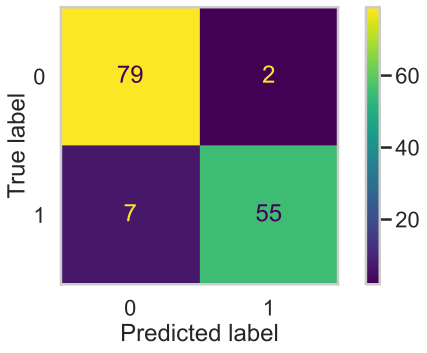

In [61]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test);
plt.grid(False)

In [62]:
metrics.accuracy_score(y_test, y_pred)

0.9370629370629371

In [63]:
metrics.precision_score(y_test, y_pred)

np.float64(0.9649122807017544)

In [64]:
metrics.recall_score(y_test, y_pred)

np.float64(0.8870967741935484)

### What if we choose a different threshold?

🤔 **Question**: Suppose we choose a threshold **higher** than 0.5. What will happen to our model's precision and recall?

🙋 **Answer**: Precision will increase, while recall will decrease*.

- If the "bar" is higher to predict 1, then we will have fewer positives in general, and thus fewer false positives.

- The denominator in $\text{precision} = \frac{TP}{TP + FP}$ will get smaller, and so precision will increase.

- However, the number of false negatives will increase, as we are being more "strict" about what we classify as positive, and so $\text{recall} = \frac{TP}{TP + FN}$ will decrease.

- *It is possible for either or both to stay the same, if changing the threshold slightly (e.g. from 0.5 to 0.500001) doesn't change any predictions.

Similarly, if we decrease our threshold, our model's precision will decrease, while its recall will increase. 

### Trying several thresholds

The classification threshold is not actually a parameter of `LogisticRegression`, because the threshold doesn't change the coefficients ($w^*$s) of the logistic regression model itself (see [this article](https://stats.stackexchange.com/questions/390186/is-decision-threshold-a-hyperparameter-in-logistic-regression#:~:text=The%20decision%20threshold%20is%20not,how%20hyper%2Dparameters%20are%20tuned.) for more details).

- Still, the threshold affects our decision rule, so we can tune it using cross-validation (which is not what we're doing below).
- It's also useful to plot how our metrics change as we change the threshold.

In [65]:
thresholds = np.arange(0.01, 1.01, 0.01)
precisions = np.array([])
recalls = np.array([])

for t in thresholds:
    y_pred = clf.predict_proba(X_test)[:, 1] >= t
    precisions = np.append(precisions, metrics.precision_score(y_test, y_pred, zero_division=1))
    recalls = np.append(recalls, metrics.recall_score(y_test, y_pred))

Let's visualize the results.

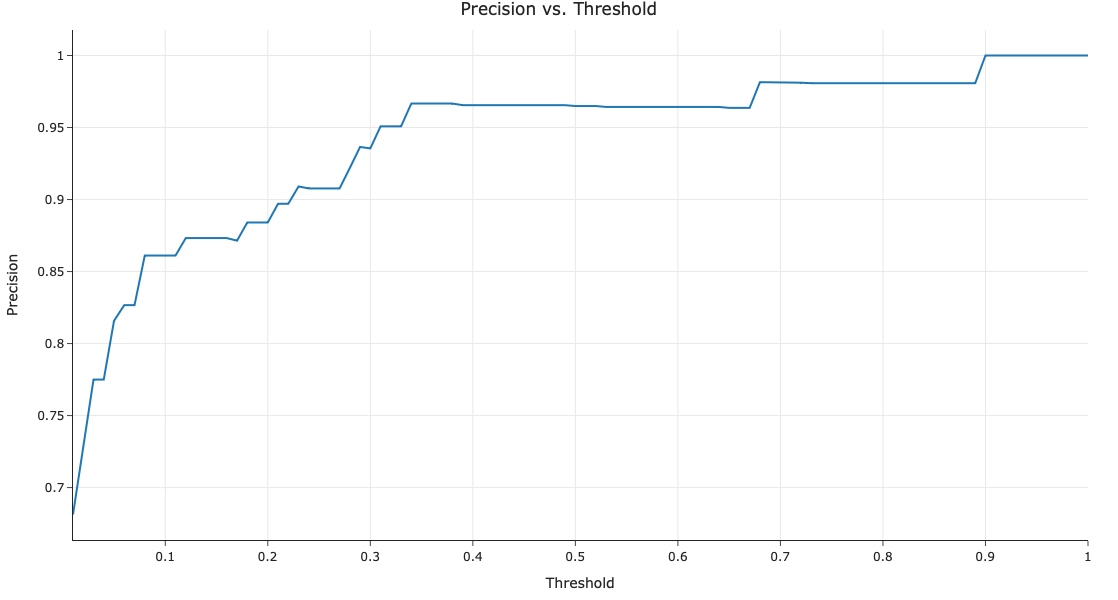

In [67]:
px.line(x=thresholds, y=precisions,
        labels={'x': 'Threshold', 'y': 'Precision'}, title='Precision vs. Threshold', width=1000, height=600)

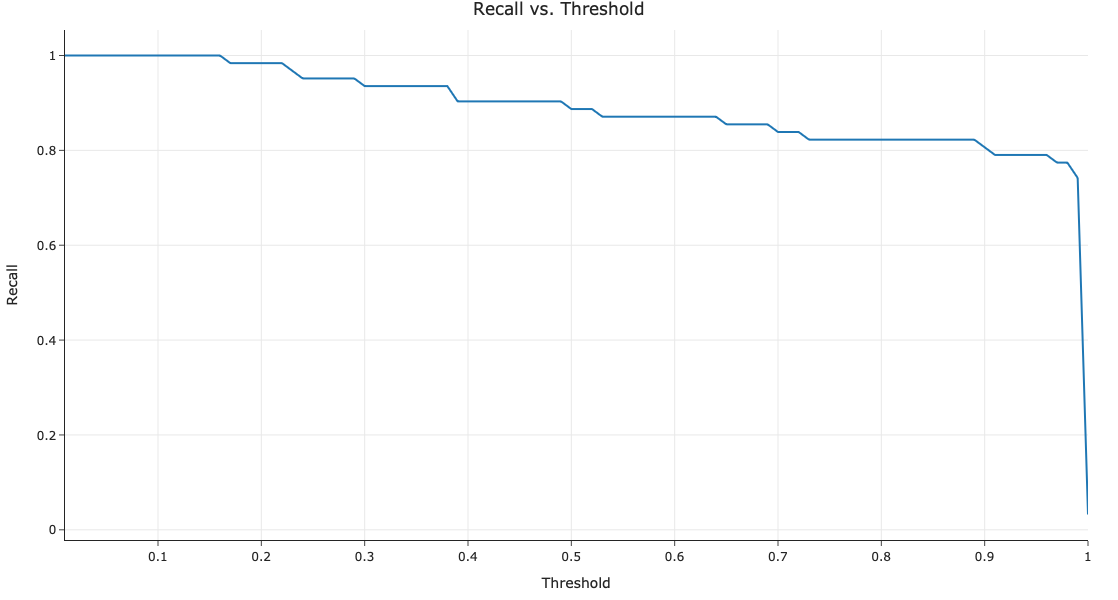

In [68]:

px.line(x=thresholds, y=recalls, 
        labels={'x': 'Threshold', 'y': 'Recall'}, title='Recall vs. Threshold', width=1000, height=600)

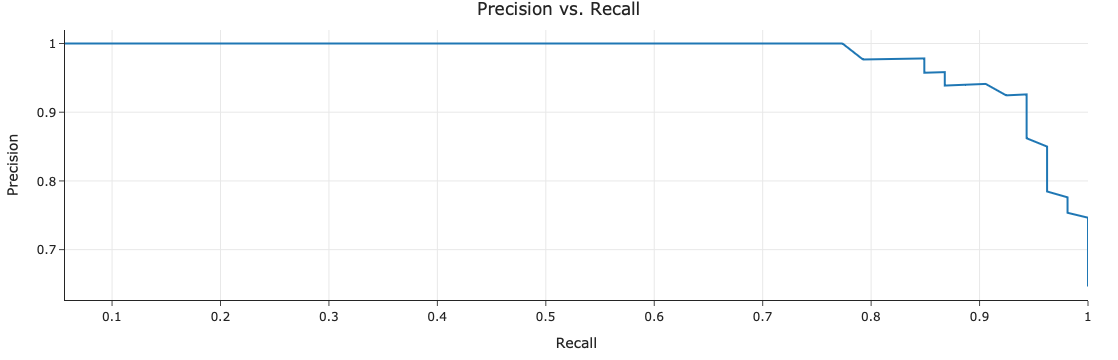

In [24]:
px.line(x=recalls, y=precisions, hover_name=thresholds, 
        labels={'x': 'Recall', 'y': 'Precision'}, title='Precision vs. Recall')

The above curve is called a precision-recall (or PR) curve.

🤔 **Question**: Based on the PR curve above, what threshold would you choose?

### Combining precision and recall

If we care equally about a model's precision $PR$ and recall $RE$, we can combine the two using a single metric called the **F1-score**:

$$\text{F1-score} = \text{harmonic mean}(PR, RE) = 2\frac{PR \cdot RE}{PR + RE}$$

In [69]:
pr = metrics.precision_score(y_test, clf.predict(X_test))
re = metrics.recall_score(y_test, clf.predict(X_test))

2 * pr * re / (pr + re)

np.float64(0.9243697478991597)

In [70]:
metrics.f1_score(y_test, clf.predict(X_test))

np.float64(0.9243697478991597)

Both F1-score and accuracy are overall measures of a binary classifier's performance. But remember, accuracy is misleading in the presence of class imbalance, and doesn't take into account the kinds of errors the classifier makes.

In [71]:
metrics.accuracy_score(y_test, clf.predict(X_test))

0.9370629370629371

### Other evaluation metrics for binary classifiers

We just scratched the surface! This [excellent table from Wikipedia](https://en.wikipedia.org/wiki/Template:Diagnostic_testing_diagram) summarizes the many other metrics that exist.

<center><img src='imgs/wiki-table.png' width=75%></center>

If you're interested in exploring further, a good next metric to look at is **true negative rate (i.e. specificity)**, which is the analogue of recall for true negatives.

## Model fairness

### Fairness: why do we care?

- Sometimes, a model performs better for certain groups than others; in such cases we say the model is **unfair**.

- Since ML models are now used in processes that significantly affect human lives, it is important that they are fair!
    * Job applications and college admissions.
    * Criminal sentencing and parole grants.
    * Predictive policing.
    * Credit and loans.

### Model fairness

- We'd like to build a model that is _fair_, meaning that it performs the same for individuals within a group and individuals outside of the group.

- What do we mean by "perform"? What do we mean by "the same"?

<center><img src="imgs/parity.png" width=900></center>

### Parity measures for classifiers

Suppose $C$ is a classifier we've already trained, and $A$ is some binary attribute that denotes whether an individual is a member of a _sensitive_ group – that is, a group we want to avoid discrimination for (e.g. $A = \text{age is less than 25}$).

- $C$ achieves **accuracy parity** if $C$ has the same accuracy for individuals in $A$ and individuals not in $A$.
    - **Example**: $C$ is a binary classifier that determines whether someone receives a loan.
        - If the classifier predicts correctly, then either $C$ approves the loan and it is paid off, or $C$ denies the loan and it would have defaulted.
        - If $C$ achieves accuracy parity, then the proportion of correctly classified loans should be the same for those under 25 and those over 25.

- $C$ achieves **precision (or recall) parity** if $C$ has the same precision (or recall) for individuals in $A$ and individuals not in $A$.
    - Recall parity is often called "true positive rate parity."

- $C$ achieves **demographic parity** if the proportion of predictions that are positive is equal for individuals in $A$ and individuals not in $A$. 

- With the exception of demographic parity, the parity measures above all involve checking whether some evaluation metric from Lecture 17 is equal across two groups.

### More on parity measures

- Which parity metric should you care about? It depends on your specific dataset and what types of errors are important!

- Many of these parity measures are **impossible** to satisfy simultaneously!

- The classifier parity metrics mentioned on the previous slide are only a few of the many possible parity metrics. See these [DSC 167 notes](https://afraenkel.github.io/fairness-book/content/05-parity-measures.html) for more details, including more formal explanations.

- These don't apply for regression models; for those, we may care about **RMSE parity** or **$R^2$ parity**. There is also a notion of demographic parity for regression models, but it is outside of the scope of DSC 80.

### Example: Loan approval

As you know from Project 2, LendingClub was a "peer-to-peer lending company"; they [used to publish](https://www.lendingclub.com/info/download-data.action) a dataset describing the loans that they approved.

* `'tag'`: whether loan was repaid in full (1.0) or defaulted (0.0).
* `'loan_amnt'`: amount of the loan in dollars.
* `'emp_length'`: number of years employed.
* `'home_ownership'`: whether borrower owns (1.0) or rents (0.0).
* `'inq_last_6mths'`: number of credit inquiries in last six months.
* `'revol_bal'`: revolving balance on borrows accounts.
* `'age'`: age in years of the borrower (protected attribute).

In [72]:
loans = pd.read_csv(Path('data') / 'loan_vars1.csv', index_col=0)
loans.head()

,loan_amnt,emp_length,home_ownership,inq_last_6mths,revol_bal,age,tag
268309,6400.0,0.0,1.0,1.0,899.0,22.0,0.0
301093,10700.0,10.0,1.0,0.0,29411.0,19.0,0.0
1379211,15000.0,10.0,1.0,2.0,9911.0,48.0,0.0
486795,15000.0,10.0,1.0,2.0,15883.0,35.0,0.0
1481134,22775.0,3.0,1.0,0.0,17008.0,39.0,0.0


The total amount of money loaned was over 5 billion dollars! 

In [73]:
loans['loan_amnt'].sum()

np.float64(5706507225.0)

In [74]:
loans.shape[0]

386772

### Predicting `'tag'`

Let's build a classifier that predicts whether or not a loan was paid in full. If we were a bank, we could use our trained classifier to determine whether to approve someone for a loan!

In [75]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [76]:
X = loans.drop('tag', axis=1)
y = loans.tag
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [77]:
clf = RandomForestClassifier(n_estimators=50)
clf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=50)

Recall, a prediction of 1 means that we predict that the loan will be paid in full.

In [78]:
y_pred = clf.predict(X_test)
y_pred

array([1., 0., 1., ..., 1., 0., 1.])

In [79]:
clf.score(X_test, y_test)

0.7144053861189538

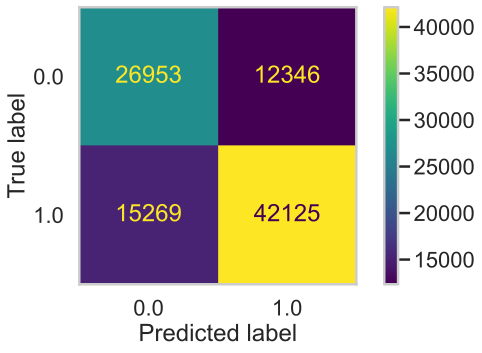

In [80]:
ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test);
plt.grid(False)

### Precision

$$\text{precision} = \frac{TP}{TP+FP}$$

Precision describes the **proportion of loans that were approved that would have been paid back**.

In [81]:
metrics.precision_score(y_test, y_pred)

np.float64(0.7733472857116631)

If we subtract the precision from 1, we get the proportion of loans that were approved that **would not** have been paid back. This is known as the **false discovery rate**.

$$\frac{FP}{TP + FP} = 1 - \text{precision}$$

In [82]:
1 - metrics.precision_score(y_test, y_pred)

np.float64(0.2266527142883369)

### Recall

$$\text{recall} = \frac{TP}{TP + FN}$$

Recall describes the **proportion of loans that would have been paid back that were actually approved**.

In [83]:
metrics.recall_score(y_test, y_pred)

np.float64(0.7339617381607834)

If we subtract the recall from 1, we get the proportion of loans that would have been paid back that **were denied**. This is known as the **false negative rate**.

$$\frac{FN}{TP + FN} = 1 - \text{recall}$$

In [84]:
1 - metrics.recall_score(y_test, y_pred)

np.float64(0.26603826183921664)

From both the perspective of the bank and the lendee, a high false negative rate is bad!
- The bank left money on the table – the lendee would have paid back the loan, but they weren't approved for a loan.
- The lendee deserved the loan, but weren't given one.

### False negative rate by age

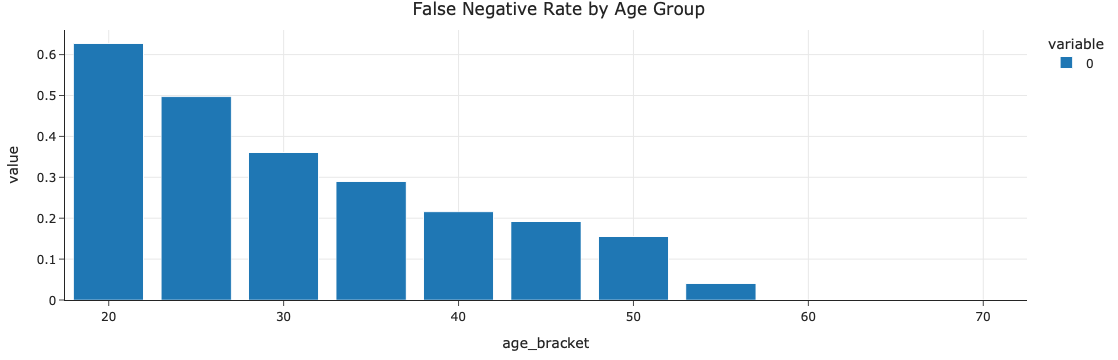

In [85]:
results = X_test
results['age_bracket'] = results['age'].apply(lambda x: 5 * (x // 5 + 1))
results['prediction'] = y_pred
results['tag'] = y_test

(
    results
    .groupby('age_bracket')
    [['tag', 'prediction']]
    .apply(lambda x: 1 - metrics.recall_score(x['tag'], x['prediction']))
    .plot(kind='bar', title='False Negative Rate by Age Group')
)

### Computing parity measures

- $C$: Our random forest classifier (1 if we approved the loan, 0 if we denied it).
- $A$: Whether or not they were under 25 (1 if under, 0 if above).

In [88]:
results['is_young'] = (results['age'] < 25).replace({True: 'young', False: 'old'})

First, let's compute the proportion of loans that were approved in each group. If these two numbers are the same, $C$ achieves demographic parity.

In [90]:
results.groupby('is_young')['prediction'].mean()

is_young
old      0.68
young    0.30
Name: prediction, dtype: float64

$C$ evidently does not achieve demographic parity – older people are approved for loans far more often! Note that this doesn't factor in whether they were _correctly_ approved or _incorrectly_ approved.

Now, let's compute the accuracy of $C$ in each group. If these two numbers are the same, $C$ achieves accuracy parity.

In [91]:
compute_accuracy = lambda x: metrics.accuracy_score(x['tag'], x['prediction'])

In [92]:
(
    results
    .groupby('is_young')
    [['tag', 'prediction']]
    .apply(compute_accuracy)
    .rename('accuracy')
)

is_young
old      0.73
young    0.68
Name: accuracy, dtype: float64

Hmm... These numbers look much more similar than before!

### Is this difference in accuracy significant?

Let's run a **permutation test** to see if the difference in accuracy is significant.
- **Null Hypothesis**: The classifier's accuracy is the same for both young people and old people, and any differences are due to chance.
- **Alternative Hypothesis**: The classifier's accuracy is higher for old people.
- Test statistic: Difference in accuracy (young minus old).
- Significance level: 0.01.

In [93]:
obs = (results
       .groupby('is_young')
       [['tag', 'prediction']]
       .apply(compute_accuracy)
       .diff()
       .iloc[-1])
obs

np.float64(-0.04748870207680067)

In [94]:
diff_in_acc = []
for _ in range(500):
    s = (
        results[['is_young', 'prediction', 'tag']]
        .assign(is_young=np.random.permutation(results['is_young']))
        .groupby('is_young')
        [['tag', 'prediction']]
        .apply(compute_accuracy)
        .diff()
        .iloc[-1]
    )
    
    diff_in_acc.append(s)

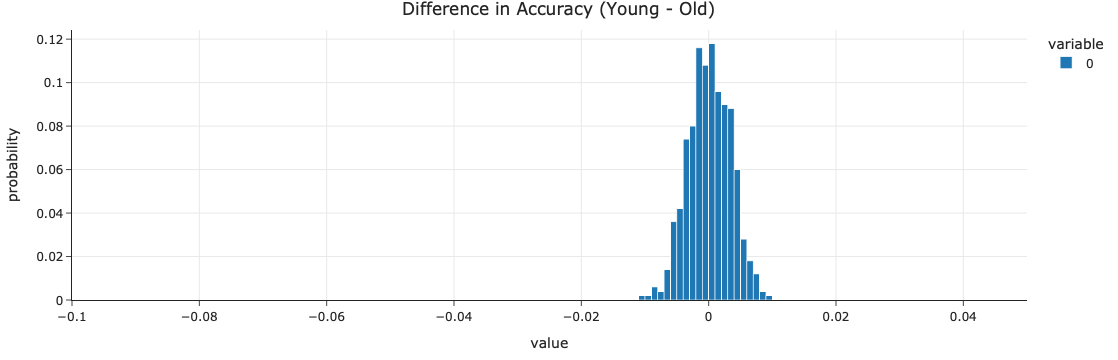

In [95]:
fig = pd.Series(diff_in_acc).plot(kind='hist', histnorm='probability', nbins=20,
                            title='Difference in Accuracy (Young - Old)')
fig.add_vline(x=obs, line_color='red')
fig.update_layout(xaxis_range=[-0.1, 0.05])

It seems like the difference in accuracy across the two groups **is significant**, despite being only ~5%. Thus, $C$ likely does not achieve accuracy parity.

### Ethical questions of fairness

<div class="alert alert-warning">
    <h3>Question 🤔 (Answer at <a href="https://dsc80.com/q">dsc80.com/q</a>)</h3>

Code: `fair`
</div>


- **Question**: Is it "fair" to deny loans to younger people at a higher rate?
- Make an argument for "yes", then make an argument for "no".

- Federal law prevents age from being used as a determining factor in denying a loan.

Not only should we use `'age'` to determine whether or not to approve a loan, but we also shouldn't use other features that are strongly correlated with `'age'`, like `'emp_length'`.

In [46]:
loans

,loan_amnt,emp_length,home_ownership,inq_last_6mths,revol_bal,age,tag
268309,6400.0,0.0,1.0,1.0,899.0,22.0,0.0
301093,10700.0,10.0,1.0,0.0,29411.0,19.0,0.0
1379211,15000.0,10.0,1.0,2.0,9911.0,48.0,0.0
...,...,...,...,...,...,...,...
1150493,5000.0,1.0,1.0,0.0,3842.0,52.0,1.0
686485,6000.0,10.0,0.0,0.0,6529.0,36.0,1.0
342901,15000.0,8.0,1.0,1.0,16060.0,39.0,1.0


## Summary

### Summary

- A logistic regression model makes classifications by first predicting a probability and then thresholding that probability.
    - The default threshold is 0.5; by moving the threshold, we change the balance between precision and recall.
- To assess the parity of your model:
    - Choose an evaluation metric, e.g. precision, recall, or accuracy for classifiers, or RMSE or $R^2$ for regressors.
    - Choose a sensitive binary attribute, e.g. "age < 25" or "is data science major", that divides your data into two groups.
    - Conduct a permutation test to verify whether your model's evaluation criteria is similar for individuals in both groups.

## Parting Thoughts

<center><img src="imgs/ds-lifecycle.svg" width="40%"></center>

### Course goals ✅

In this course, you...

* **Practiced** translating potentially vague questions into quantitative questions about measurable observations.
* **Learned** to reason about 'black-box' processes (e.g. complicated models).
* **Understood** computational and statistical implications of working with data.
* **Learned** to use real data tools (e.g. love the documentation!).
* **Got** a taste of the "life of a data scientist".

### Course outcomes ✅

Now, you...

* Are **prepared** for internships and data science "take home" interviews!
* Are **ready** to create your own portfolio of personal projects.
* Have the **background** and **maturity** to succeed in the upper-division.

### Topics covered ✅

We learnt a lot this quarter.

- Week 1: From BabyPandas to Pandas
- Week 2: DataFrames
- Week 3: Messy Data, Hypothesis Testing
- Week 4: Missing Values and Imputation
- Week 5: HTTP, **Midterm Exam**
- Week 6: Web Scraping, Regex
- Week 7: Text Features, Regression
- Week 8: Feature Engineering
- Week 9: Generalization, CV, Decision Trees
- Week 10: Random Forests, Classifier Evaluation

### Thank you!

- This course would not have been possible without our tutors and TAs.

- Don't be a stranger – our contact information is at [dsc80.com/staff](https://dsc80.com/staff)!

    - This quarter's course website will remain online permanently at [dsc-courses.github.io](https://dsc-courses.github.io).

- **Apply to be a tutor in the future!** [Learn more here](https://datascience.ucsd.edu/current-students/dsc-tutors/).

## Building a Data Science Career

### Do Grades Matter?

- Not as much as you probably think.

What you might imagine:

1. Student works hard to get As in their DSC classes.
1. High GPA looks good on resume.
1. Resume leads to interview, student aces interview.
1. Good job!

But this is what I actually see:

1. Student works hard to get As in ALL OF THEIR classes and takes a minor / double major. 
1. High GPA looks decent on resume, but lots of students have high GPAs.
1. Resume doesn't stand out very much, and student has trouble finding job after graduation.

### An Alternate Route

1. Student takes fewer classes in order to do AMAZING work in one class (e.g. really interested in data visualization).
1. Professor: Wow, that was the best class work in YEARS, you should totally join my research group!
1. Student works with PhD students and professor on cutting-edge research, years ahead of what's available in industry.
1. Student's resume is packed with interesting projects that VERY FEW other students have, leading to an AWESOME JOB after graduation.
    1. Or, student applies to grad school and their professor can write them a super good letter.

### There are many ways to be excellent

1. Take more classes, get good grades
    1. Highly structured -- professor gives you problems.

Less-structured efforts where you pick the problem to work on:

1. Go beyond the requirements in a course you really like.
1. Help redesign a course.
1. Conduct an independent study.
1. Do research.
1. Create a startup / non-profit.

Higher risk of failure, but you'll learn a lot more than if you just take classes!

### My Advice for People Starting Out

1. Next quarter, take fewer courses, and be okay with getting Bs in some courses if it means you get to invest lots of time into the one course you really like.
1. Really stand out in one course you like. Here are some examples:
    1. Going 2x above project requirements, then talk to your professor about your work.
    1. Ask lots of good questions after every lecture.
    1. Come to office hours regularly with questions about topics beyond the course.
1. At the end of the quarter, ask your professor if you can help with their research group.

### Let's Be Pragmatic

- Yes, you need to work hard to develop strong technical skills!
- But the best jobs come through people that know you, not by submitting your resume into a pool of thousands of applicants.
    - You should spend time thinking about how you can make use of being at UCSD to grow your network.
    - PhD students and professors are a good place to start, but not the only way.

### How to cold-email and actually get responses

1. Pick a topic of interest.
2. Do an independent project around that topic.
    1. Small and punchy is better than big! [See some of Simon Willison's posts for examples.](https://simonwillison.net/2022/Jul/9/gpt-3-explain-code/)
3. Put your project online as a publicly viewable webpage (like what you're doing for your final project!).
4. Write an email that looks like this:

```
Hi {name},

My name is {name} and I'm an undergrad at UCSD studying {major}.

I'm really interested in learning more about your research in {topic} since I'm also working on projects in that area. For example, I wrote about my latest work on {my project} here: {url}.

Would you have some time in the next few weeks for a 30-min chat?
```

Key points:

1. Email PhD students, not professors!
    1. Most professors I know get lots of low-quality cold emails every day, so many of them just ignore. But PhD students are less famous so they'll be happy that someone is interested in their work.
1. Keep it short. If they can't read it in 10 seconds, it's too long!
1. Share your URL. That shows that you actually have interest in the topic.
1. Ask for a 30-min chat (not 1 hour). Again, people are busy!
1. If they agree to meet, don't ask to join their lab right away. Talk to them about their work, then at the end, say something like, "Thanks again for taking the time to meet with me! This work fits really well with my interests, so I was wondering whether there might be opportunities to work with you as part of your research group."
1. If they say yes, great! If they say no, ask them for other people they know who might also be a good fit.

### Shifting your mentality

- What you want to avoid:
    - "Please give me a research position, I'll do anything."
    - Even though this might be truly how you feel!
- What you want to think instead:
    - I'm a rising professional with lots of highly valuable skills.
    - I also have specific interests.
    - I'm looking for the right position that aligns with my interests so that I can contribute in a productive and meaningful way.

## Be persistent!

<center><h3>Good luck on the Final Exam, and enjoy your summer break! 🎉</h3></center>